# VIMS saturation, SNR and errorbars

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pyvims import QUB, VIMS
from pyvims.wget import wget

In [2]:
IMG_ID = '1487294146_1'

In [3]:
if not Path(f'v{IMG_ID}.qub').exists():
    wget(f'https://vims.univ-nantes.fr/qub/{IMG_ID}', f'v{IMG_ID}.qub')

if not Path(f'C{IMG_ID}_ir.cub').exists():
    wget(f'https://vims.univ-nantes.fr/cube/C{IMG_ID}_ir.cub', f'C{IMG_ID}_ir.cub')

In [4]:
qub = QUB(IMG_ID)

qub

<QUB> QUB: 1487294146_1
 - Size: (48, 30)
 - Mode: ('HI-RES', 'HI-RES')
 - Start time: 2005-02-17 00:49:21.773000
 - Stop time: 2005-02-17 01:03:13.051000
 - Exposure: (np.float64(26.0), np.float64(0.54)) sec
 - Duration: 0:13:51.278000
 - Target: ENCELADUS

In [5]:
cube = VIMS(IMG_ID)

cube

<VIMS> Cube: 1487294146_1
 - Size: (48, 30)
 - Channel: IR
 - Mode: HI-RES
 - Start time: 2005-02-17 00:49:21.773000+00:00
 - Stop time: 2005-02-17 01:03:13.051000+00:00
 - Exposure: 0.5493149999999999 sec
 - Duration: 0:13:51.278000
 - Main target: ENCELADUS
 - Flyby: 03CA

## Single pixel saturation

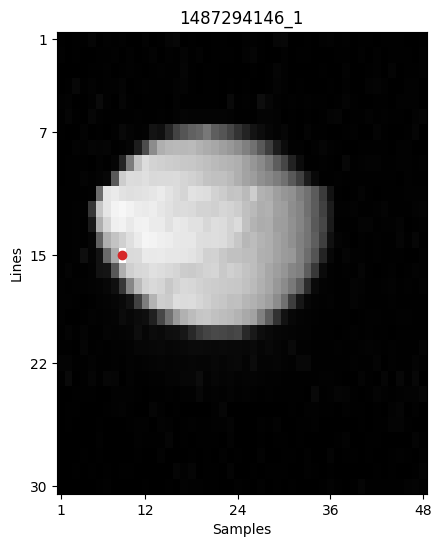

In [6]:
S, L = 9, 15

_, ax = plt.subplots(figsize=(6, 6))

cube.plot('2.03', title=f'{IMG_ID}', ax=ax)

ax.plot(S, L, 'o', color='tab:red');

In [7]:
wvlns = qub.wvlns[96:]
dn = qub.data.data[L - 1, 96:, S - 1].astype(int)
background = qub.side_plane[L - 1, 96:].astype(int)
saturation = dn + background >= 4095
snr = (dn + background) / background

iof = cube.data[:, L - 1, S - 1]
iof_min = iof * (1 - 1 / snr)
iof_max = iof * (1 + 1 / snr)

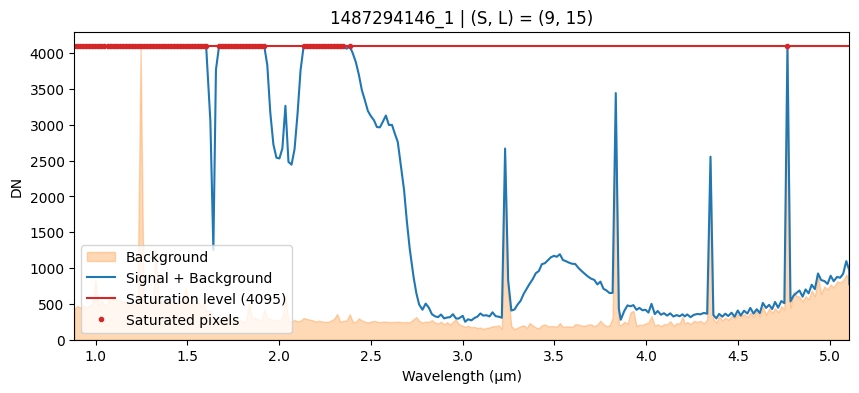

In [8]:
_, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(wvlns, 0, background, color='tab:orange', alpha=0.3, label='Background')
ax.plot(wvlns, dn + background, color='tab:blue', label='Signal + Background')
ax.axhline(4095, color='tab:red', label='Saturation level (4095)')
ax.plot(wvlns, np.ma.array(dn + background, mask=~saturation), '.', color='tab:red', label='Saturated pixels')

ax.legend(loc='lower left')

ax.set_xlim(wvlns[0], wvlns[-1])
ax.set_ylim(0, None)

ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel('DN')
ax.set_title(f'{qub.img_id} | (S, L) = ({S}, {L})');

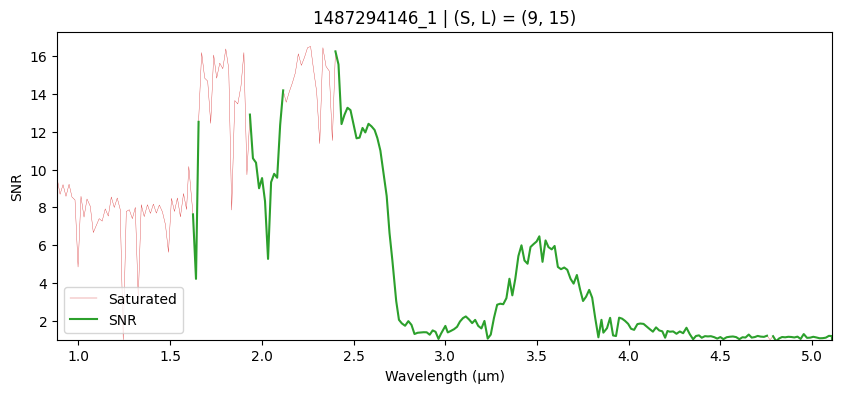

In [9]:
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(wvlns, snr, color='tab:red', lw=0.25, label='Saturated')
ax.plot(wvlns, np.ma.array(snr, mask=saturation), color='tab:green', label='SNR')

ax.legend(loc='lower left')

ax.set_xlim(wvlns[0], wvlns[-1])
ax.set_ylim(1, None)

ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel('SNR')
ax.set_title(f'{qub.img_id} | (S, L) = ({S}, {L})');

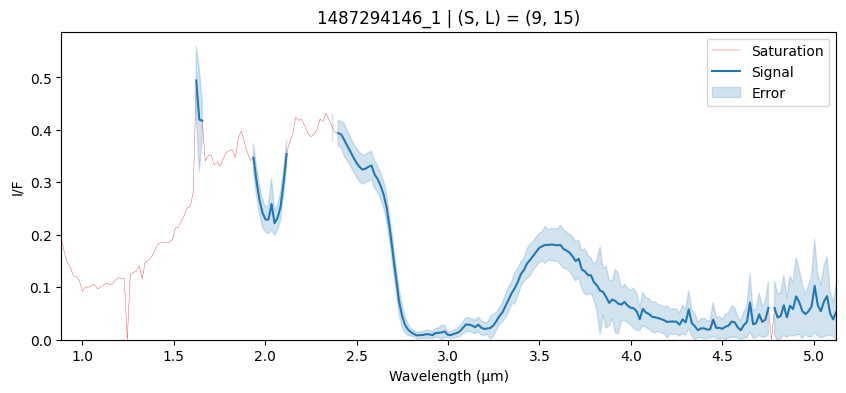

In [10]:
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(cube.wvlns, iof, color='tab:red', lw=0.25, label='Saturation')
ax.plot(cube.wvlns, np.ma.array(iof, mask=saturation), color='tab:blue', label='Signal')

ax.fill_between(cube.wvlns, np.ma.array(iof_min, mask=saturation), np.ma.array(iof_max, mask=saturation), color='tab:blue', alpha=0.2, label='Error')

ax.legend()

ax.set_xlim(cube.wvlns[0], cube.wvlns[-1])
ax.set_ylim(0, None)

ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel('I/F')
ax.set_title(f'{cube.img_id} | (S, L) = ({S}, {L})');

## All pixels saturation and SNR

In [11]:
dn_ir = qub.data.data[:, 96:, :]
bg_ir = np.broadcast_to(qub.side_plane[:, 96:, np.newaxis].astype(int), dn_ir.shape)
saturation_ir = np.moveaxis(dn_ir + bg_ir >= 4095, 0, 1)
snr_ir = np.moveaxis((dn_ir + bg_ir) / bg_ir, 0, 1)

iof_ir_error_min = cube.data * (1 - 1 / snr_ir)
iof_ir_error_max = cube.data * (1 + 1 / snr_ir)

saturation_ir.shape

(256, 30, 48)

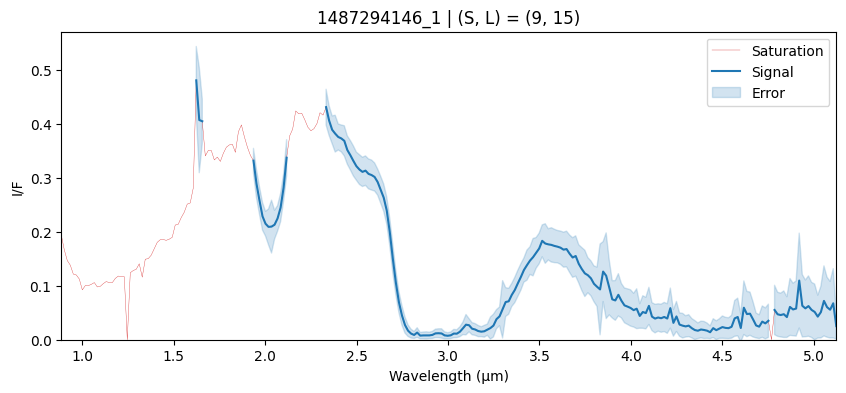

In [12]:
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(cube.wvlns, cube.data[:, L, S], color='tab:red', lw=0.25, label='Saturation')
ax.plot(cube.wvlns, np.ma.array(cube.data[:, L, S], mask=saturation_ir[:, L, S]), color='tab:blue', label='Signal')

ax.fill_between(cube.wvlns, np.ma.array(iof_ir_error_min[:, L, S], mask=saturation_ir[:, L, S]), np.ma.array(iof_ir_error_max[:, L, S], mask=saturation_ir[:, L, S]), color='tab:blue', alpha=0.2, label='Error')

ax.legend()

ax.set_xlim(cube.wvlns[0], cube.wvlns[-1])
ax.set_ylim(0, None)

ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel('I/F')
ax.set_title(f'{cube.img_id} | (S, L) = ({S}, {L})');

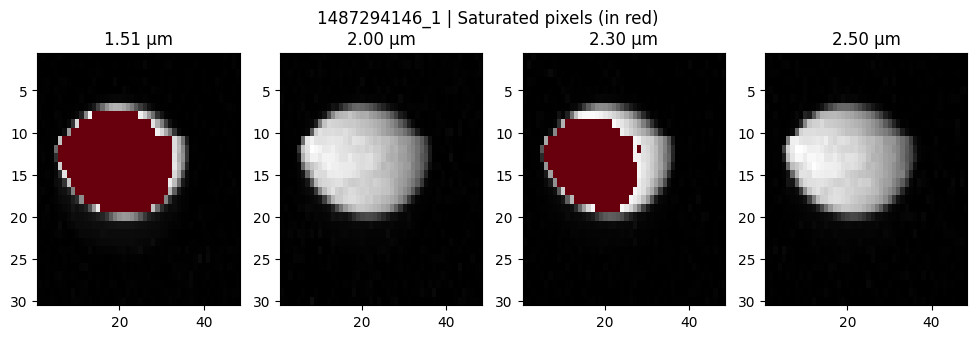

In [13]:
wvlns = [1.5, 2.0, 2.3, 2.5]

_, axes = plt.subplots(ncols=len(wvlns), figsize=(12, 3.5))

for ax, w in zip(axes, wvlns):
    i = cube._index(w)
    ax.imshow(cube.data[i], extent=cube.extent, cmap='gray')
    ax.imshow(np.ma.array(saturation_ir[i], mask=~saturation_ir[i]), extent=cube.extent, cmap='Reds_r')
    ax.set_title(f'{cube.wvlns[i]:.2f} µm');

    ax.set_aspect(2 if cube._is_hr else 1)

plt.suptitle(f'{IMG_ID} | Saturated pixels (in red)');